In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation

In [32]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.titlesize': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 12,

    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',

    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True
})

In [33]:
def format_plot(ax, title, xlabel, ylabel, horizontal=False):

    ax.set_title(title, pad=20)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if horizontal:
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.grid(axis='y', visible=False)
    else:
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.grid(axis='x', visible=False)

In [34]:
def get_clean_mask(data, threshold=3.5):
    """
    Apply Iglewicz and Hoaglin's robust outlier detection.
    Returns: Boolean mask (True = Valid, False = Outlier)
    """
    median = np.median(data)
    mad = median_abs_deviation(data, scale='normal')
    modified_z_score = 0.6745 * (data - median) / mad
    return modified_z_score.abs() < threshold

def get_limits(data):
    """
    Calculates a SYMMETRIC limit centered on 0.
    1. Takes the Absolute Value of the errors.
    2. Finds the Nth percentile of those absolute values.
    3. Returns [-Limit, +Limit].
    """
    abs_data = data.abs()
    limit = np.percentile(abs_data, 99)
    return limit

In [35]:
filePath = '../Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)

In [36]:
df_bioimpedance = df[[
    'Weight',
    'Total Body Water (TBW)',         # Measured in kg
    'Extracellular Water (ECW)',      # Measured in kg
    'Intracellular Water (ICW)',      # Measured in kg
    'Extracellular Fluid/Total Body Water (ECF/TBW)', # Derived Fluid Ratio
    'Total Body Fat Ratio (TBFR) (%)',# Percentage of total mass
    'Lean Mass (LM) (%)',             # Percentage of fat-free mass
    'Body Protein Content (Protein) (%)', # Protein composition percentage
    'Visceral Fat Rating (VFR)',      # Corresponds to "Visceral Adiposity Index" in text [cite: 61]
    'Bone Mass (BM)',                 # Measured in kg
    'Muscle Mass (MM)',               # Measured in kg
    'Obesity (%)',                    # Degree of obesity percentage
    'Total Fat Content (TFC)',        # Measured in kg
    'Visceral Fat Area (VFA)',        # Measured in kg
    'Visceral Muscle Area (VMA) (Kg)' # Measured in kg
]].copy()

df_bioimpedance

,Weight,Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Extracellular Fluid/Total Body Water (ECF/TBW),Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Visceral Fat Rating (VFR),Bone Mass (BM),Muscle Mass (MM),Obesity (%),Total Fat Content (TFC),Visceral Fat Area (VFA),Visceral Muscle Area (VMA) (Kg)
0,92.8,52.9,21.2,31.7,40.00,19.20,80.84,18.88,9,3.7,71.4,23.40,17.8,10.60,39.7
1,94.5,43.1,19.5,23.6,45.00,32.80,67.20,16.68,15,3.2,60.3,38.80,31.0,18.40,32.7
2,91.1,47.2,20.1,27.1,43.00,27.30,72.67,16.35,15,3.3,62.9,41.70,24.9,16.20,34.0
3,67.7,41.4,17.0,24.4,41.00,15.80,84.19,16.90,6,2.9,54.1,9.00,10.7,6.50,29.2
4,89.6,51.4,20.0,31.4,39.00,20.00,80.02,16.81,8,3.5,68.2,28.60,17.9,10.40,37.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,88.8,47.6,20.0,28.0,42.01,24.66,75.23,16.13,11,3.3,63.5,14.39,21.9,13.58,34.2
315,53.4,29.3,12.3,17.0,42.00,23.60,76.40,15.96,2,2.1,38.7,1.50,12.6,5.10,22.2
316,96.6,49.2,21.0,28.2,43.00,28.80,71.22,15.87,16,3.4,65.4,48.40,27.8,17.10,35.6
317,88.4,50.2,19.9,30.3,40.00,21.10,78.85,16.30,8,3.4,66.3,28.30,18.7,11.00,36.1


In [37]:
# Track A: Physics (Summation) | TBW - (ECW + ICW)
col_TBW_calc_sum = 'TBW_calc_sum'
df_bioimpedance[col_TBW_calc_sum] = df_bioimpedance['Extracellular Water (ECW)'] + df_bioimpedance['Intracellular Water (ICW)']

col_TBW_disc_sum = 'TBW_disc_sum'
df_bioimpedance[col_TBW_disc_sum] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_sum]

# Track B: Logic (Ratio) | TBW - ECW / (Ratio/100)
col_TBW_calc_ratio = 'TBW_calc_ratio'
df_bioimpedance[col_TBW_calc_ratio] = df_bioimpedance['Extracellular Water (ECW)'] / (df_bioimpedance['Extracellular Fluid/Total Body Water (ECF/TBW)'] / 100)

col_TBW_disc_ratio = 'TBW_disc_ratio'
df_bioimpedance[col_TBW_disc_ratio] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_ratio]

# Track C: 4-Component Model | TBW - (Weight - Fat - Bone - Protein - 0.013*Weight)
epsilon_4C = df_bioimpedance['Weight']*0.013

col_TFC_calc_ratio = 'TFC_calc_ratio'
df_bioimpedance[col_TFC_calc_ratio] = (df_bioimpedance['Weight'] * (df_bioimpedance['Total Body Fat Ratio (TBFR) (%)'] / 100))

col_TPC_calc_ratio = 'TPC_calc_ratio'
df_bioimpedance[col_TPC_calc_ratio] = (df_bioimpedance['Weight'] * (df_bioimpedance['Body Protein Content (Protein) (%)'] / 100))

col_TBW_calc_4C = 'TBW_calc_4C'
df_bioimpedance[col_TBW_calc_4C] = df_bioimpedance['Weight'] - df_bioimpedance[col_TFC_calc_ratio] - df_bioimpedance['Bone Mass (BM)'] - df_bioimpedance[
    col_TPC_calc_ratio] - epsilon_4C

col_TBW_disc_4C = 'TBW_disc_4C'
df_bioimpedance[col_TBW_disc_4C] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_4C]

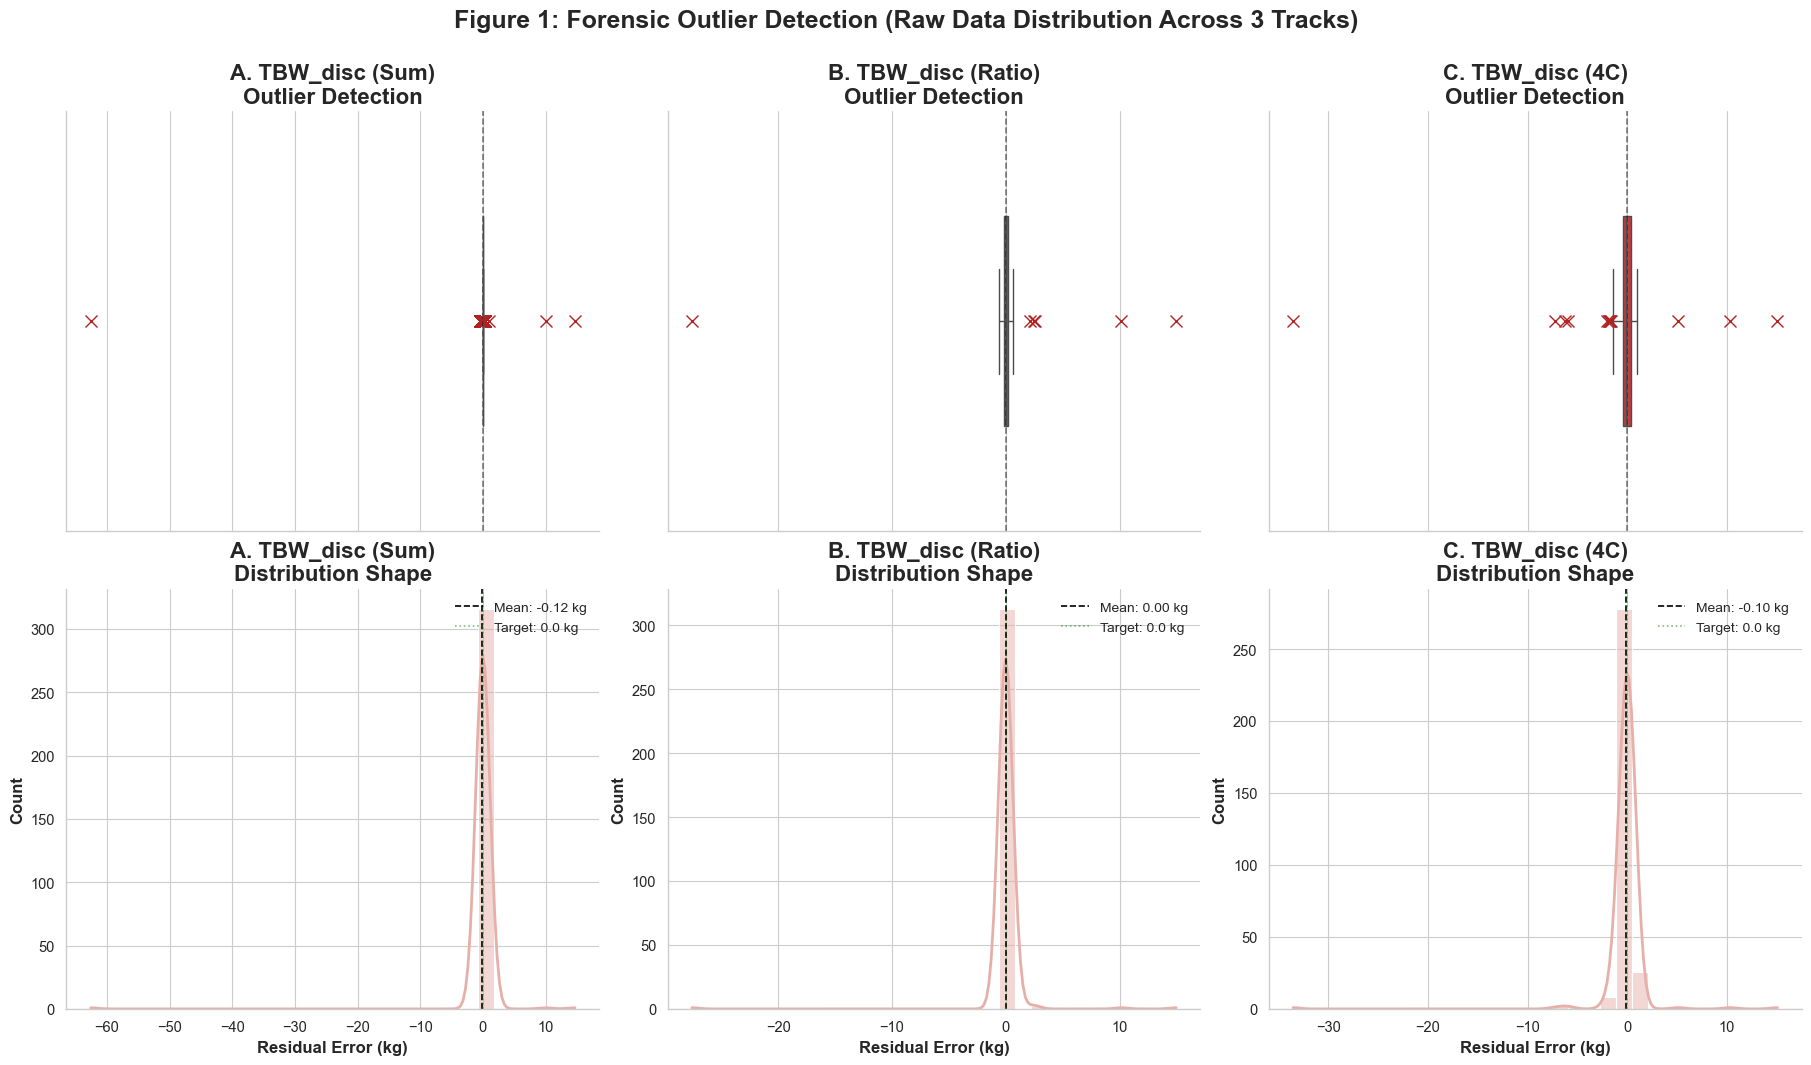

In [38]:
#(Figure 1: Distribution Analysis) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True, sharex='col')

tracks = [
    ('A. TBW_disc (Sum)'    , col_TBW_disc_sum),
    ('B. TBW_disc (Ratio)'  , col_TBW_disc_ratio),
    ('C. TBW_disc (4C)'     , col_TBW_disc_4C)
]

for i, (title, col) in enumerate(tracks):
    data = df_bioimpedance[col]

    # Upper Plot: Boxplot
    sns.boxplot(x=data, ax=axes[0, i], color='tab:red', width=0.5,
                flierprops={"marker": "x", "markeredgecolor": "firebrick", "markersize": 8})
    axes[0, i].set_title(f"{title}\nOutlier Detection", fontweight='bold')
    axes[0, i].axvline(0, color='black', linestyle='--', alpha=0.5)

    # Lower Plot: Histogram
    # Safety Check: Prevent crash on empty columns
    if not data.isnull().all():
        sns.histplot(x=data, ax=axes[1, i], color='#E6B0AA', bins=30, kde=True,
                     line_kws={'linewidth': 2, 'color': 'firebrick'})

        mean_val = data.mean()
        axes[1, i].axvline(mean_val, color='black', linestyle='--', label=f'Mean: {mean_val:.2f} kg')
        axes[1, i].axvline(0, color='green', linestyle=':', alpha=0.5, label='Target: 0.0 kg')

    axes[1, i].set_title(f"{title}\nDistribution Shape", fontweight='bold')
    axes[1, i].set_xlabel("Residual Error (kg)")
    axes[1, i].legend(loc='upper right', fontsize=10)

plt.suptitle("Figure 1: Forensic Outlier Detection (Raw Data Distribution Across 3 Tracks)",
             y=1.05, fontsize=18, fontweight='bold')
plt.show()

In [39]:
TBW_disc_sum_lim_val = get_limits(df_bioimpedance[col_TBW_disc_sum])
TBW_disc_ratio_lim_val = get_limits(df_bioimpedance[col_TBW_disc_ratio])

# 2. GENERATE MASKS (Using the new symmetric limits)
TBW_disc_fit_sum_lim = (df_bioimpedance[col_TBW_disc_sum].abs() < TBW_disc_sum_lim_val)
TBW_disc_fit_ratio_lim = (df_bioimpedance[col_TBW_disc_ratio].abs() < TBW_disc_ratio_lim_val)

TBW_disc_fail_both_lim = ~TBW_disc_fit_sum_lim & ~TBW_disc_fit_ratio_lim
TBW_disc_fail_ratio_lim = TBW_disc_fit_sum_lim & ~TBW_disc_fit_ratio_lim
TBW_disc_fail_sum_lim = ~TBW_disc_fit_sum_lim & TBW_disc_fit_ratio_lim
TBW_disc_fit_both_lim = TBW_disc_fit_sum_lim & TBW_disc_fit_ratio_lim

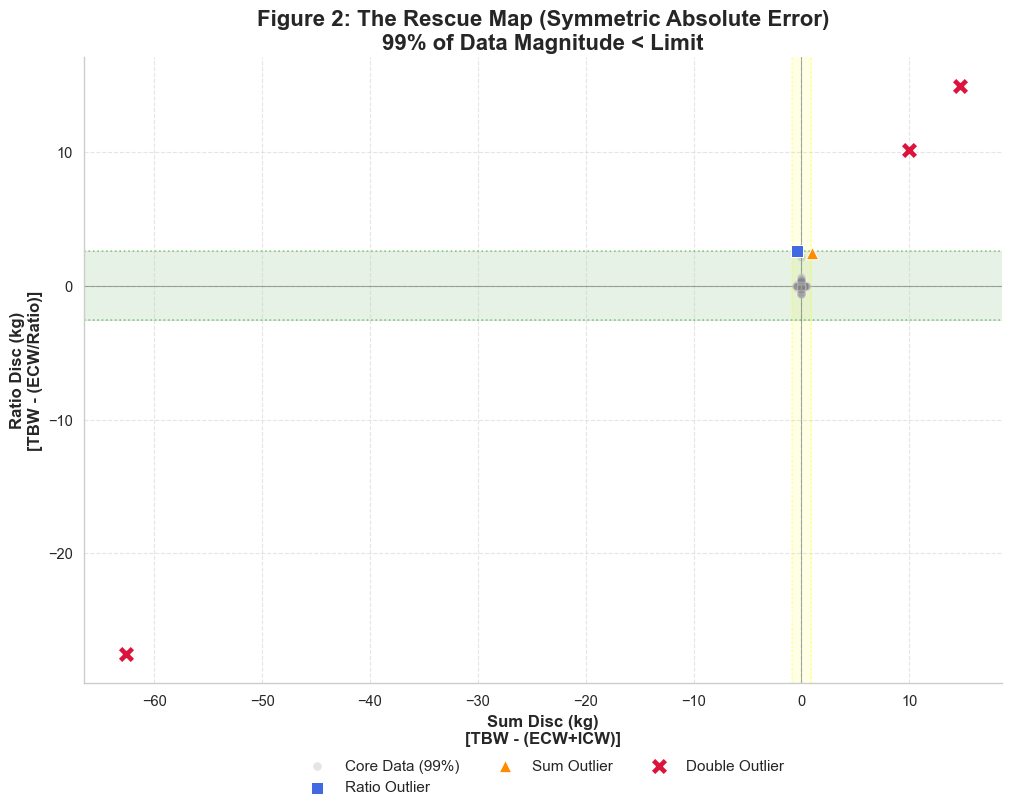

In [40]:
# --- 2. Figure 2: The Rescue Map (Symmetric Absolute Percentiles) ---
fig2, ax2 = plt.subplots(figsize=(10, 8), constrained_layout=True)

# A. DRAW THE ZONES (Perfectly Centered Cross)
ax2.axvspan(-TBW_disc_sum_lim_val, TBW_disc_sum_lim_val, color='yellow', alpha=0.1, zorder=0)
ax2.axhspan(-TBW_disc_ratio_lim_val, TBW_disc_ratio_lim_val, color='green', alpha=0.1, zorder=0)

# Dotted boundaries for visibility
ax2.axvline(-TBW_disc_sum_lim_val, color='yellow', linestyle=':', alpha=0.4)
ax2.axvline(TBW_disc_sum_lim_val, color='yellow', linestyle=':', alpha=0.4)
ax2.axhline(-TBW_disc_ratio_lim_val, color='green', linestyle=':', alpha=0.4)
ax2.axhline( TBW_disc_ratio_lim_val, color='green', linestyle=':', alpha=0.4)

# Center lines
ax2.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.3, zorder=1)
ax2.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.3, zorder=1)

# B. SCATTER PLOTS
sns.scatterplot(data=df_bioimpedance[TBW_disc_fit_both_lim], x=col_TBW_disc_sum, y=col_TBW_disc_ratio,
                color='gray', alpha=0.2, s=40, label=f'Core Data (99%)', ax=ax2, zorder=2)

sns.scatterplot(data=df_bioimpedance[TBW_disc_fail_ratio_lim], x=col_TBW_disc_sum, y=col_TBW_disc_ratio,
                color='royalblue', s=80, marker='s', label='Ratio Outlier', ax=ax2, zorder=3)

sns.scatterplot(data=df_bioimpedance[TBW_disc_fail_sum_lim], x=col_TBW_disc_sum, y=col_TBW_disc_ratio,
                color='darkorange', s=80, marker='^', label='Sum Outlier', ax=ax2, zorder=4)

sns.scatterplot(data=df_bioimpedance[TBW_disc_fail_both_lim], x=col_TBW_disc_sum, y=col_TBW_disc_ratio,
                color='crimson', s=150, marker='X', label='Double Outlier', ax=ax2, zorder=5)

ax2.set_title(f"Figure 2: The Rescue Map (Symmetric Absolute Error)\n99% of Data Magnitude < Limit",
              fontweight='bold', fontsize=16)
ax2.set_xlabel("Sum Disc (kg)\n[TBW - (ECW+ICW)]", fontweight='bold')
ax2.set_ylabel("Ratio Disc (kg)\n[TBW - (ECW/Ratio)]", fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5, zorder=0)

ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
           ncol=3, frameon=False, fontsize=11)

plt.show()

In [41]:
col_TBW_fixed = 'TBW_fixed'
df_bioimpedance[col_TBW_fixed] = df['Total Body Water (TBW)']
col_TBW_fix_status = 'TBW_fixed_status'
df_bioimpedance[col_TBW_fix_status] = False

# CASE 1: Ratio Failed -> Use Sum
df_bioimpedance.loc[TBW_disc_fail_ratio_lim, col_TBW_fixed] = df_bioimpedance.loc[TBW_disc_fail_ratio_lim, col_TBW_calc_sum]
df_bioimpedance.loc[TBW_disc_fail_ratio_lim, col_TBW_fix_status] = True

# CASE 2: Sum Failed -> Use Ratio
df_bioimpedance.loc[TBW_disc_fail_sum_lim, col_TBW_fixed] = df_bioimpedance.loc[TBW_disc_fail_sum_lim, col_TBW_calc_ratio]
df_bioimpedance.loc[TBW_disc_fail_sum_lim, col_TBW_fix_status] = True

# === CASE 3: Both Failed -> Fallback to Ratio ===
df_bioimpedance.loc[TBW_disc_fail_both_lim, col_TBW_fixed] = df_bioimpedance.loc[TBW_disc_fail_both_lim, col_TBW_calc_ratio]
df_bioimpedance.loc[TBW_disc_fail_both_lim, col_TBW_fix_status] = True

In [42]:
col_TBW_mean_raw = 'TBW_mean_raw'
df_bioimpedance[col_TBW_mean_raw] = (df_bioimpedance['Total Body Water (TBW)'] + df_bioimpedance[col_TBW_calc_4C]) / 2
col_TBW_diff_raw = 'TBW_diff_raw'
df_bioimpedance[col_TBW_diff_raw] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_4C]
col_TBW_mean_fixed = 'TBW_mean_fixed'
df_bioimpedance[col_TBW_mean_fixed] = (df_bioimpedance[col_TBW_fixed] + df_bioimpedance[col_TBW_calc_4C]) / 2
col_TBW_diff_fixed = 'TBW_diff_fixed'
df_bioimpedance[col_TBW_diff_fixed] = df_bioimpedance[col_TBW_fixed] - df_bioimpedance[col_TBW_calc_4C]

In [43]:
# fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True, constrained_layout=True)
#
# # Colors
# palette_raw = {'Valid Data (Unchanged)': 'navy', 'Repaired Data (Fixed)': 'firebrick'}
# palette_fix = {'Valid Data (Unchanged)': 'navy', 'Repaired Data (Fixed)': 'tab:green'}
# markers = {'Valid Data (Unchanged)': 'o', 'Repaired Data (Fixed)': 'X'}
#
# # --- PLOT A ---
# ax1 = axes[0]
# # Replaced df with df_bioimpedance
# sns.scatterplot(data=df_bioimpedance, x=col_mean_raw, y=col_diff_raw, hue=col_TBW_fix_status, style=col_TBW_fix_status,
#                 palette=palette_raw, markers=markers, s=80, alpha=0.6, ax=ax1, legend=False)
#
# # Stats (Replaced df with df_bioimpedance)
# mean_raw, sd_raw = df_bioimpedance[col_diff_raw].mean(), df_bioimpedance[col_diff_raw].std()
# loa_upper, loa_lower = mean_raw + 1.96*sd_raw, mean_raw - 1.96*sd_raw
#
# # Apply User Format
# format_plot(ax1, f"A. Pre-Repair: Raw vs 4-Comp\n(SD={sd_raw:.2f})",
#             "Mean TBW (Measured + Model) / 2", "Difference (Measured - Model)")
#
# # Add Lines & Text
# ax1.axhline(mean_raw, color='black', lw=2)
# ax1.axhline(loa_upper, color='gray', ls='--', lw=1.5)
# ax1.axhline(loa_lower, color='gray', ls='--', lw=1.5)
# # Replaced df with df_bioimpedance for min() calls
# ax1.text(df_bioimpedance[col_mean_raw].min(), loa_upper + 0.2, f'+1.96 SD ({loa_upper:.2f})', color='firebrick', fontweight='bold')
# ax1.text(df_bioimpedance[col_mean_raw].min(), loa_lower - 0.2, f'-1.96 SD ({loa_lower:.2f})', color='firebrick', fontweight='bold', va='top')
#
# # --- PLOT B ---
# ax2 = axes[1]
# # Replaced df with df_bioimpedance
# sns.scatterplot(data=df_bioimpedance, x=col_mean_fixed, y=col_diff_fixed, hue=col_TBW_fix_status, style=col_TBW_fix_status,
#                 palette=palette_fix, markers=markers, s=80, alpha=0.8, ax=ax2)
#
# # Stats (Replaced df with df_bioimpedance)
# mean_fix, sd_fix = df_bioimpedance[col_diff_fixed].mean(), df_bioimpedance[col_diff_fixed].std()
# loa_upper_fix, loa_lower_fix = mean_fix + 1.96*sd_fix, mean_fix - 1.96*sd_fix
#
# # Apply User Format
# format_plot(ax2, f"B. Post-Repair: Restored vs 4-Comp\n(SD={sd_fix:.2f})",
#             "Mean TBW (Restored + Model) / 2", "")
#
# # Add Lines & Text
# ax2.axhline(mean_fix, color='black', lw=2)
# ax2.axhline(loa_upper_fix, color='gray', ls='--', lw=1.5)
# ax2.axhline(loa_lower_fix, color='gray', ls='--', lw=1.5)
# # Replaced df with df_bioimpedance for min() and max() calls
# ax2.text(df_bioimpedance[col_mean_fixed].min(), loa_upper_fix + 0.2, f'+1.96 SD ({loa_upper_fix:.2f})', color='tab:green', fontweight='bold')
# ax2.text(df_bioimpedance[col_mean_fixed].max(), 0, "  <-- Restored", color='tab:green', va='center', fontweight='bold')
#
# # Legend
# handles, labels = ax2.get_legend_handles_labels()
# ax2.legend(handles, ['Valid Data', 'Repaired Data'], loc='upper right', frameon=True)
#
# plt.suptitle("Figure 3: Methodological Verification (Bland-Altman)", y=1.05, fontsize=18, fontweight='bold')
# plt.show()

In [44]:
# # --- 1. DATA PREP (Fixing the Bug) ---
# # Map boolean keys to strings to prevent "missing keys" ValueError in Seaborn
# df_bioimpedance['Fix_Label'] = df_bioimpedance[col_TBW_fix_status].map({True: 'Repaired', False: 'Valid'})
#
# # --- 2. SETUP PLOT (Comparison Mode) ---
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
#
# # ==========================================
# # PANEL A: Pre-Repair (Raw vs 4C)
# # ==========================================
# mean_raw = df_bioimpedance['Diff_Raw'].mean()
# sd_raw = df_bioimpedance['Diff_Raw'].std()
# loa_up_raw = mean_raw + 1.96 * sd_raw
# loa_low_raw = mean_raw - 1.96 * sd_raw
#
# sns.scatterplot(
#     data=df_bioimpedance, x='Mean_Raw', y='Diff_Raw',
#     color='gray', alpha=0.5, s=60, ax=ax1, label='Raw Data'
# )
#
# format_plot(ax1, f"A. Pre-Repair: Raw vs 4-Component\n(SD={sd_raw:.2f} kg)",
#             "Mean TBW (Raw + 4C) / 2", "Difference (Raw - 4C)")
#
# # Reference Lines (A)
# ax1.axhline(mean_raw, color='black', lw=2)
# ax1.axhline(loa_up_raw, color='black', ls=':', lw=1.5)
# ax1.axhline(loa_low_raw, color='black', ls=':', lw=1.5)
# ax1.text(df_bioimpedance['Mean_Raw'].min(), loa_up_raw, f'+1.96 SD ({loa_up_raw:.2f})', va='bottom', fontweight='bold')
#
# # ==========================================
# # PANEL B: Post-Repair (Restored vs 4C)
# # ==========================================
# mean_fix = df_bioimpedance['Diff_Final'].mean()
# sd_fix = df_bioimpedance['Diff_Final'].std()
# loa_up_fix = mean_fix + 1.96 * sd_fix
# loa_low_fix = mean_fix - 1.96 * sd_fix
#
# # Palette must use the STRING keys we created in Step 1
# palette_clean = {'Repaired': 'tab:green', 'Valid': 'tab:red'}
# markers_clean = {'Repaired': 'X', 'Valid': 'o'}
#
# sns.scatterplot(
#     data=df_bioimpedance, x='Mean_Final', y='Diff_Final',
#     hue='Fix_Label', style='Fix_Label',  # Use the String column
#     palette=palette_clean, markers=markers_clean,
#     s=90, alpha=0.8, ax=ax2
# )
#
# format_plot(ax2, f"B. Post-Repair: Restored vs 4-Component\n(SD={sd_fix:.2f} kg)",
#             "Mean TBW (Restored + 4C) / 2", "")
#
# # Reference Lines (B)
# ax2.axhline(mean_fix, color='black', lw=2, label=f'Mean Bias: {mean_fix:.2f}')
# ax2.axhline(loa_up_fix, color='tab:green', ls='--', lw=2)
# ax2.axhline(loa_low_fix, color='tab:green', ls='--', lw=2)
#
# # --- OUTLIER ANNOTATION (Points outside the graph limits) ---
# outliers = df_bioimpedance[
#     (df_bioimpedance['Diff_Final'] > loa_up_fix) |
#     (df_bioimpedance['Diff_Final'] < loa_low_fix)
# ]
#
# for idx, row in outliers.iterrows():
#     # Annotate with index number
#     ax2.annotate(
#         f"{idx}",
#         (row['Mean_Final'], row['Diff_Final']),
#         xytext=(4, 4), textcoords='offset points',
#         fontsize=9, color='darkred', fontweight='bold'
#     )
#
# # Final Polish
# ax2.text(df_bioimpedance['Mean_Final'].min(), loa_up_fix, f'+1.96 SD ({loa_up_fix:.2f})', color='tab:green', va='bottom', fontweight='bold')
# ax2.legend(loc='upper right', frameon=True, title="Data Status")
#
# plt.suptitle("Figure 3: Methodological Verification (Bland-Altman Comparison)", y=1.02, fontsize=18, fontweight='bold')
# plt.tight_layout()
# plt.show()
#
# # Print outlier details for academic reporting
# print(f"Detected {len(outliers)} points outside limits of agreement (Index IDs):")
# print(outliers.index.tolist())